In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('Salary_Data.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


<Figure size 300x300 with 0 Axes>

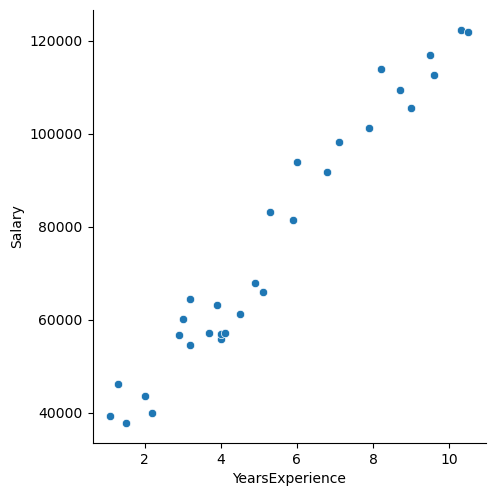

In [4]:
plt.figure(figsize= (3, 3))
sns.pairplot(data , x_vars = ["YearsExperience"] , y_vars = ["Salary"] , size= 5 , kind = "scatter")
plt.show() 

In [5]:
x = data.iloc[: , :-1]
y = data.iloc[: , 1]


In [6]:
print(x )

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [7]:
print(y)

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64


In [8]:
x_train ,x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 0)


In [9]:
my_model =LinearRegression()
my_model.fit(x_train , y_train)

LinearRegression()

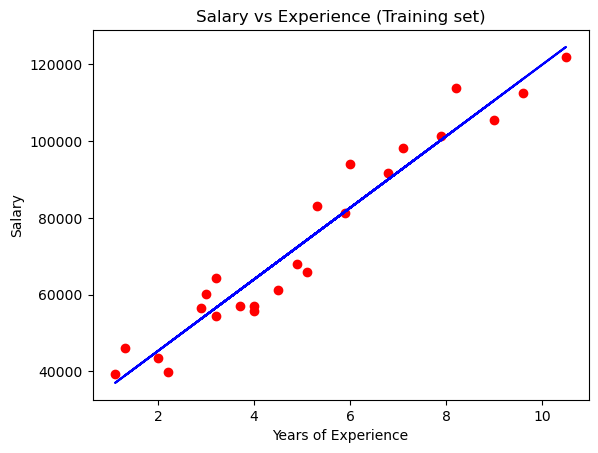

In [10]:
plt.scatter(x_train, y_train, color = 'red')
plt.plot(x_train, my_model.predict(x_train), color='blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()



In [11]:
y_pred = my_model.predict(x_test)

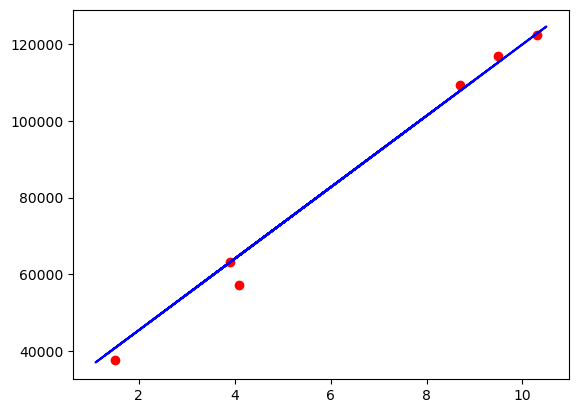

In [12]:
plt.scatter(x_test, y_test, color = 'red')
plt.plot(x_train, my_model.predict(x_train), color='blue')

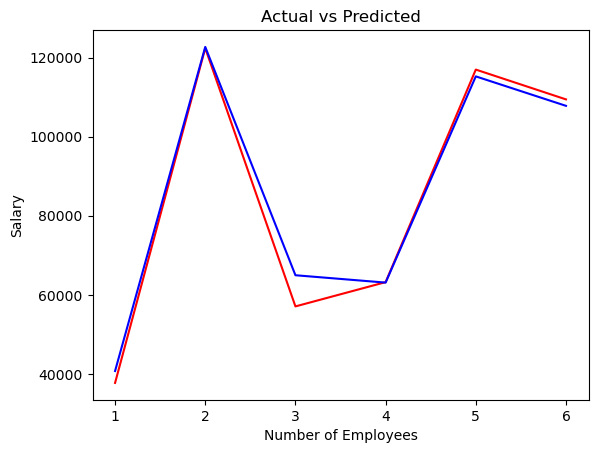

In [13]:
c = [i for i in range (1 , len(y_test)+1 )]
plt.plot(c , y_test , color = 'red')
plt.plot (c , y_pred , color = 'blue')
plt.title('Actual vs Predicted') 
plt.xlabel('Number of Employees')
plt.ylabel('Salary')
plt.show()

In [14]:
mse = mean_squared_error(y_test , y_pred)
print(mse)
rmse = np.sqrt(mse)
print(rmse)


12823412.298126562
3580.979237321345


In [15]:
print(data.mean())
#error = 4.711%

YearsExperience        5.313333
Salary             76003.000000
dtype: float64


In [16]:
rsq = r2_score(y_test , y_pred)
rsq

0.988169515729126

In [17]:
my_model.intercept_

26780.099150628186

In [18]:
my_model.coef_

array([9312.57512673])

In [19]:
y_hat = 9312.57 * 1.1 +26780
y_hat

37023.827000000005

In [20]:
y_hat = 9312.57 * 1.3 +26780
y_hat

38886.341

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

In [22]:
poly = PolynomialFeatures(degree = 15)
x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)

In [23]:
poly_model = LinearRegression()
poly_model.fit(x_poly_train , y_train)

LinearRegression()

In [24]:
x_range = np.linspace(x.min(), x.max() , 100).reshape(-1 , 1 )
x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

In [25]:
y_poly_pred = poly_model.predict(x_poly_train)

In [26]:
y_poly_test = poly_model.predict(x_poly_test)

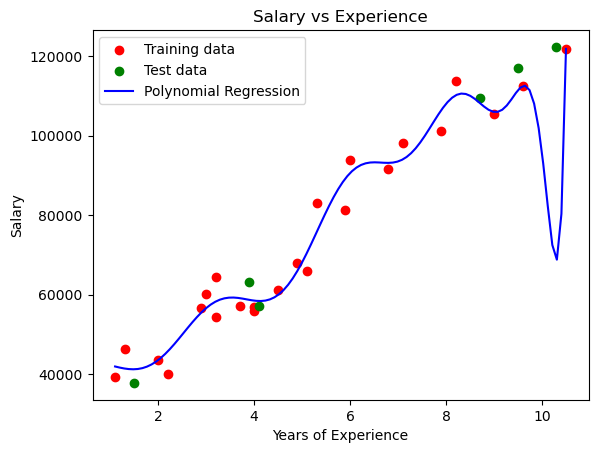

In [27]:
plt.scatter(x_train, y_train, color='red', label='Training data')
plt.scatter(x_test, y_test, color='green', label='Test data')
plt.plot(x_range, y_range_pred, color='blue', label='Polynomial Regression')
plt.title('Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()